# Substituční šifra – ukázka řešení

V notebooku je stručně ukázaný celý postup: příprava referenčního textu, tvorba bigramové matice, šifrování, hodnocení textu a krátká ukázka kryptoanalýzy.

Dlouhé zpracování všech 60 souborů se zde znovu nespouští. Na konci se jen načtou hotové výsledky.

## 1. Importy a cesty

Notebook může být spuštěný z kořene projektu i ze složky `notebooks`, proto si nejdřív najde `pyproject.toml`.

In [1]:
from pathlib import Path
import random
import sys

import numpy as np

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None


def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Kořen projektu nebyl nalezen.")


PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from substitution_cipher import (
    ALPHABET,
    SubstitutionCipher,
    get_bigrams,
    plausibility,
    substitute_decrypt,
    substitute_encrypt,
    transition_matrix,
)
from substitution_cipher.bigrams import absolute_bigram_matrix
from substitution_cipher.cipher import random_key, validate_key
from substitution_cipher.io_utils import load_matrix
from substitution_cipher.paths import (
    CLEAN_REFERENCE_TEXT_PATH,
    OUTPUT_DIR,
    RAW_REFERENCE_TEXT_PATH,
    REFERENCE_MATRIX_PATH,
    TEACHER_EXAMPLE_DIR,
)
from substitution_cipher.preprocessing import clean_text, validate_clean_text

print("Projekt:", PROJECT_ROOT.name)
print("Abeceda:", ALPHABET)

Projekt: python
Abeceda: ABCDEFGHIJKLMNOPQRSTUVWXYZ_


## 2. Referenční text

Použitý je pouze text **Války s mloky**. Surový text se dá získat skriptem `scripts/download_reference_text.py`, ale notebook ho znovu nestahuje.

In [2]:
raw_text = RAW_REFERENCE_TEXT_PATH.read_text(encoding="utf-8")
clean_reference = CLEAN_REFERENCE_TEXT_PATH.read_text(encoding="utf-8").strip()

validate_clean_text(clean_reference)

print("Surový text:", len(raw_text), "znaků")
print("Vyčištěný text:", len(clean_reference), "znaků")
print()
print("Surový začátek:")
print(raw_text[:250].replace("\n", " "))
print()
print("Vyčištěný začátek:")
print(clean_reference[:250])

Surový text: 401043 znaků
Vyčištěný text: 381933 znaků

Surový začátek:
Kdybyste hledali ostrůvek Tana Masa na mapě, našli byste jej právě na rovníku kousek na západ od Sumatry; ale kdybyste se zeptali na palubě lodi Kandong Bandoeng kapitána J. van Tocha, co to je tahle Tana Masa, před kterou právě zakotvil, nadával by 

Vyčištěný začátek:
KDYBYSTE_HLEDALI_OSTRUVEK_TANA_MASA_NA_MAPE_NASLI_BYSTE_JEJ_PRAVE_NA_ROVNIKU_KOUSEK_NA_ZAPAD_OD_SUMATRY_ALE_KDYBYSTE_SE_ZEPTALI_NA_PALUBE_LODI_KANDONG_BANDOENG_KAPITANA_J_VAN_TOCHA_CO_TO_JE_TAHLE_TANA_MASA_PRED_KTEROU_PRAVE_ZAKOTVIL_NADAVAL_BY_CHVILI


Čištění odstraní diakritiku a interpunkci, převede text na velká písmena a ponechá jen `A-Z_`.

In [3]:
example = "Příliš žluťoučký kůň běží přes dvůr."
print(clean_text(example))

PRILIS_ZLUTOUCKY_KUN_BEZI_PRES_DVUR


## 3. Bigramy a referenční matice

Bigramy jsou sousední dvojice znaků. Z textu `ABC` vzniknou `AB` a `BC`.

In [4]:
example_bigrams = get_bigrams("KRYPTOSYSTEM")
print(example_bigrams)

['KR', 'RY', 'YP', 'PT', 'TO', 'OS', 'SY', 'YS', 'ST', 'TE', 'EM']


In [5]:
reference_bigrams = get_bigrams(clean_reference)
absolute_matrix = absolute_bigram_matrix(reference_bigrams)
smoothed_matrix = transition_matrix(reference_bigrams)
calculated_matrix = smoothed_matrix / smoothed_matrix.sum()
saved_matrix = load_matrix(REFERENCE_MATRIX_PATH)

print("Počet bigramů:", len(reference_bigrams))
print("Shape matice:", saved_matrix.shape)
print("Součet:", saved_matrix.sum())
print("Nulové hodnoty:", int(np.sum(saved_matrix == 0.0)))
print("Uložená matice odpovídá výpočtu:", np.allclose(saved_matrix, calculated_matrix))

Počet bigramů: 381932
Shape matice: (27, 27)
Součet: 1.0
Nulové hodnoty: 0
Uložená matice odpovídá výpočtu: True


Nuly se před normalizací nahradí jedničkou, protože při výpočtu skóre se používá logaritmus.

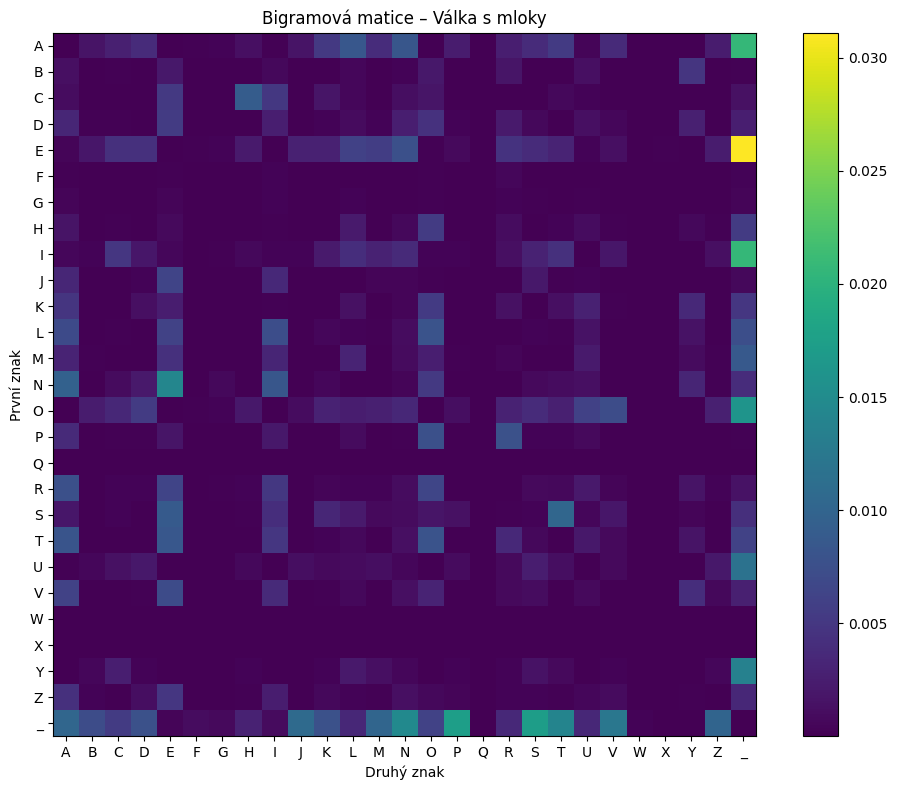

In [6]:
if plt is not None:
    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(saved_matrix)
    ax.set_xticks(range(len(ALPHABET)))
    ax.set_yticks(range(len(ALPHABET)))
    ax.set_xticklabels(ALPHABET)
    ax.set_yticklabels(ALPHABET)
    ax.set_xlabel("Druhý znak")
    ax.set_ylabel("První znak")
    ax.set_title("Bigramová matice – Válka s mloky")
    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Matplotlib není nainstalovaný.")

## 4. Šifrování a dešifrování

Klíč je permutace celé abecedy. Pro ukázku použiji náhodný klíč s pevným seedem.

In [7]:
key = random_key(seed=42)
validate_key(key)

plaintext = "AHOJ_SVETE_TOTO_JE_UKAZKA"
ciphertext = substitute_encrypt(plaintext, key)
decrypted = substitute_decrypt(ciphertext, key)

print("Plaintext: ", plaintext)
print("Ciphertext:", ciphertext)
print("Dešifrováno:", decrypted)
print("Shoda:", plaintext == decrypted)

Plaintext:  AHOJ_SVETE_TOTO_JE_UKAZKA
Ciphertext: QKYWUZHTETUEYEYUWTUVLQDLQ
Dešifrováno: AHOJ_SVETE_TOTO_JE_UKAZKA
Shoda: True


## 5. Plausibility

Skóre říká, jak dobře text odpovídá bigramovým četnostem z referenční knihy. Vyšší hodnota je lepší.

In [8]:
czech_text = clean_reference[:500]
random_text = "".join(random.Random(1).choices(ALPHABET, k=500))

print("Český text:", plausibility(czech_text, saved_matrix))
print("Náhodný text:", plausibility(random_text, saved_matrix))

Český text: -8283.182718649747
Náhodný text: -7952.109251607248


Český úryvek by měl mít vyšší skóre než náhodná posloupnost znaků.

## 6. Krátká ukázka hledání klíče

Finální běh používá 20 000 iterací. V notebooku stačí kratší ukázka, aby se dal spustit během chvíle.

In [9]:
cipher = SubstitutionCipher(saved_matrix)

source_text = clean_reference[:250]
secret_key = random_key(seed=7)
encrypted_text = cipher.encrypt(source_text, secret_key)

result = cipher.crack(
    encrypted_text,
    iterations=1_000,
    restarts=1,
    seed=1,
    polish=False,
    progress_every=0,
)

matching = sum(
    expected == actual
    for expected, actual in zip(source_text, result.plaintext)
)

print("Shodné znaky:", matching, "/", len(source_text))
print("Procento:", round(100 * matching / len(source_text), 2), "%")
print("Ukázka výsledku:")
print(result.plaintext[:200])

Restart 1/1 nejlepší plausibility: -7334.087470188675
Celkově nejlepší restart: 1, plausibility: -7334.087470188675
Shodné znaky: 166 / 250
Procento: 66.4 %
Ukázka výsledku:
KDEJESTO_HLODALI_USTVYROK_TANA_PASA_NA_PAZO_NASLI_JESTO_MOM_ZVARO_NA_VURNIKY_KUYSOK_NA_BAZAD_UD_SYPATVE_ALO_KDEJESTO_SO_BOZTALI_NA_ZALYJO_LUDI_KANDUNG_JANDUONG_KAZITANA_M_RAN_TUCHA_CU_TU_MO_TAHLO_TANA


Výsledek této krátké ukázky není podstatný pro finální hodnocení. Má jen ukázat, jak se knihovna používá.

## 7. Hotové výstupy

Teď se jen ověří, kolik výsledných souborů už existuje a jestli jsou klíče platné.

In [10]:
plaintext_files = sorted(OUTPUT_DIR.glob("*_plaintext.txt"))
key_files = sorted(OUTPUT_DIR.glob("*_key.txt"))

invalid_keys = []

for path in key_files:
    try:
        validate_key(path.read_text(encoding="utf-8").strip())
    except ValueError:
        invalid_keys.append(path.name)

print("Plaintext soubory:", len(plaintext_files))
print("Key soubory:", len(key_files))
print("Neplatné klíče:", invalid_keys)

Plaintext soubory: 60
Key soubory: 60
Neplatné klíče: []


Finální běh vytvořil 60 plaintextů a 60 klíčů.

## 8. Známý učitelský příklad

Správný plaintext a klíč se použijí pouze pro kontrolu hotového výsledku. Při samotném hledání se nepoužívají.

In [11]:
teacher_plaintext = (
    TEACHER_EXAMPLE_DIR / "text_1000_sample_1_plaintext.txt"
).read_text(encoding="utf-8").strip()

teacher_key = (
    TEACHER_EXAMPLE_DIR / "text_1000_sample_1_key.txt"
).read_text(encoding="utf-8").strip()

output_plaintext = (
    OUTPUT_DIR / "text_1000_sample_1_plaintext.txt"
).read_text(encoding="utf-8").strip()

output_key = (
    OUTPUT_DIR / "text_1000_sample_1_key.txt"
).read_text(encoding="utf-8").strip()

matching = sum(
    expected == actual
    for expected, actual in zip(teacher_plaintext, output_plaintext)
)

print("Plaintext přesně sedí:", output_plaintext == teacher_plaintext)
print("Správné znaky:", matching, "/", len(teacher_plaintext))
print("Procento:", round(100 * matching / len(teacher_plaintext), 2), "%")
print("Key přesně sedí:", output_key == teacher_key)

Plaintext přesně sedí: False
Správné znaky: 922 / 1000
Procento: 92.2 %
Key přesně sedí: False


V uloženém finálním běhu bylo správně obnoveno **922 z 1000 znaků**, tedy **92,2 %**.

Výsledek se může mezi běhy měnit, protože hledání začíná náhodným klíčem a pracuje s náhodnými výměnami.

## 9. Závěr

Bigramový model dokáže substituční šifru prolomit poměrně dobře, ale není stoprocentní. Největší problém mají kratší ciphertexty a případy, kdy se hledání zastaví v lokálním maximu.

Projekt splňuje hlavní část zadání a navíc obsahuje objektové API, lokální doladění klíče a paralelní zpracování více souborů.